In [1]:
from neuron import h, n
import matplotlib.pyplot as plt

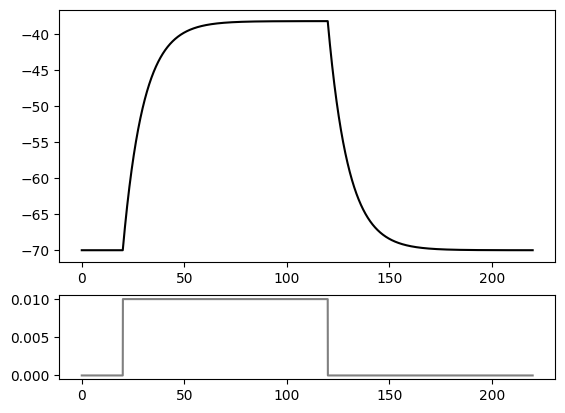

In [ ]:

n.load_file('bilayer.hoc')


soma = h.Section(name='soma')
soma.L = 10 # length µm
soma.diam = 10 # diameter µm
soma.insert('pas')# add passive properties  
soma.g_pas = 1/10000 # set the specific membrane; resistance to 10000 ohm*cm^2

stim = h.IClamp(soma(0.5))
stim.delay = 20 # start of the current injection (ms)
stim.dur= 100 # duration (ms)
stim.amp= 0.01 # amplitude (nA)

# record voltage of some and injected current
# and the time
soma_v = h.Vector()
soma_v.record(soma(0.5)._ref_v)

stim_current = h.Vector()
stim_current.record(stim._ref_i)

t = h.Vector()
t.record(h._ref_t)

# run simulation
h.tstop = 220 # set the simulation time
h.dt = 0.025
h.v_init = -70
h.run()

# plotting
f, (ax0, ax1) = plt.subplots(2,1, gridspec_kw = {'height_ratios':[3, 1]})
ax0.plot(t,soma_v, 'k')
ax1.plot(t,stim_current, 'gray', label='I (nA)')

